<a href="https://colab.research.google.com/github/Andrewodeh/DataScienceProject/blob/main/Flight_Delay_Phase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flight Delay Project — Phase 4: Final Model and Discussion

**Course:** COMP4381 Data Science and Analytics — Spring 2026
**Instructor:** Dr. Ahmad Sabbah
**Group:** Predictive Minds

| Member | Student Number |
|---|---|
| Andrew Odeh | 1222212 |
| Omar Omar | 1220027 |

**Title:** Flight Delay Prediction and Airport Punctuality Analysis Across Five European Countries

## 1. Phase 4 overview

In Phases 1–3 we built a clean **airport-day** dataset covering five European
airports (one per country): Dublin (Ireland), Copenhagen (Denmark),
Lisbon (Portugal), Brussels (Belgium) and Vienna (Austria), with daily records
for 2023–2025.

In this final phase we build a **machine learning model** that predicts, for a
given airport on a given day, **whether that day will be *delayed* or *on-time***.
This is a **binary classification** problem, which is the type of classification
the course focused on, and the algorithm we use is **Logistic Regression** — the
classifier demonstrated in the course material.

The phase follows the full modelling workflow taught in the course:
define the target → choose features and avoid data leakage → train/test split →
preprocess → fit Logistic Regression → interpret → evaluate (accuracy, precision,
recall, F1, confusion matrix) → check for under/over-fitting → predict new cases →
discuss and conclude.

### Setup
We use only the libraries covered in the course: `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scikit-learn`.

In [1]:
import io, bz2, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Rebuild the analytical dataset (from the public Phase 3 sources)


we rebuild the
exact same analytical table that Phase 3 produced, reading directly from the
permanent public source URLs:

* **EUROCONTROL** daily airport arrival ATFM delay and airport traffic (one file per year).
* **OurAirports** global airport metadata.

This is the same loading and cleaning code used in Phase 3, so the dataset here is
identical to `data/processed/flight_delay_analytical.csv` in our repository.

In [2]:
# One airport per country (ICAO codes)
AIRPORTS = ["EIDW", "EKCH", "LPPT", "EBBR", "LOWW"]   # Dublin, Copenhagen, Lisbon, Brussels, Vienna
YEARS    = [2023, 2024, 2025]

# Permanent public data URLs
DELAY_URL         = "https://www.eurocontrol.int/performance/data/download/csv/apt_dly_{year}.csv.bz2"
TRAFFIC_URL       = "https://www.eurocontrol.int/performance/data/download/csv/airport_traffic_{year}.csv"
AIRPORTS_META_URL = "https://raw.githubusercontent.com/davidmegginson/ourairports-data/main/airports.csv"

In [3]:
HEADERS = {"User-Agent": "Mozilla/5.0"}

def load_csv(url, **kwargs):
    """Download a CSV (handling EUROCONTROL .bz2 compression and Latin-1 encoding)."""
    kwargs.setdefault("encoding", "latin-1")
    r = requests.get(url, headers=HEADERS, timeout=180)
    r.raise_for_status()
    data = r.content
    if url.endswith(".bz2"):
        try:
            data = bz2.decompress(data)
        except OSError:
            pass
    return pd.read_csv(io.BytesIO(data), **kwargs)

# Load the three sources
delay_raw   = pd.concat([load_csv(DELAY_URL.format(year=y))   for y in YEARS], ignore_index=True)
traffic_raw = pd.concat([load_csv(TRAFFIC_URL.format(year=y)) for y in YEARS], ignore_index=True)
airports_meta = load_csv(AIRPORTS_META_URL)

print("Delay raw shape:  ", delay_raw.shape)
print("Traffic raw shape:", traffic_raw.shape)
print("Metadata shape:   ", airports_meta.shape)

Delay raw shape:   (302010, 28)
Traffic raw shape: (345621, 13)
Metadata shape:    (85616, 19)


In [4]:
# Keep only our 5 airports
delay   = delay_raw[delay_raw["APT_ICAO"].isin(AIRPORTS)].copy()
traffic = traffic_raw[traffic_raw["APT_ICAO"].isin(AIRPORTS)].copy()

# Parse mixed date formats safely, then reduce to a day-level date
def to_date(series):
    parsed = pd.to_datetime(series, utc=True, errors="coerce")
    return parsed.dt.tz_convert(None).dt.normalize()

delay["date"]   = to_date(delay["FLT_DATE"])
traffic["date"] = to_date(traffic["FLT_DATE"])

# Merge traffic + delay on (airport, date)
delay_cols   = ["APT_ICAO", "date", "DLY_APT_ARR_1", "FLT_ARR_1_DLY", "FLT_ARR_1_DLY_15",
                "DLY_APT_ARR_W_1", "DLY_APT_ARR_D_1"]
traffic_cols = ["APT_ICAO", "date", "APT_NAME", "STATE_NAME", "FLT_DEP_1", "FLT_ARR_1", "FLT_TOT_1"]
df = pd.merge(traffic[traffic_cols], delay[delay_cols], on=["APT_ICAO", "date"], how="inner")

# Add airport metadata
meta_cols = ["ident", "type", "latitude_deg", "longitude_deg", "elevation_ft",
             "iso_country", "iso_region", "municipality", "scheduled_service"]
df = pd.merge(df, airports_meta[meta_cols], left_on="APT_ICAO", right_on="ident", how="left").drop(columns=["ident"])

# Clean: duplicates + missing values (same rules as Phase 3)
df = df.drop_duplicates()
delay_fill = ["DLY_APT_ARR_1", "FLT_ARR_1_DLY", "FLT_ARR_1_DLY_15", "DLY_APT_ARR_W_1", "DLY_APT_ARR_D_1"]
df[delay_fill] = df[delay_fill].fillna(0)
df = df[df["FLT_ARR_1"].notna() & (df["FLT_ARR_1"] > 0)]
df = df.dropna(subset=["FLT_DEP_1", "FLT_TOT_1", "type", "elevation_ft"])

print("Analytical table shape:", df.shape)

Analytical table shape: (5477, 20)


In [5]:
# Feature engineering needed for the model (same definitions as Phase 3)
df["year"]        = df["date"].dt.year
df["month"]       = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()

def get_season(m):
    if m in [12, 1, 2]:  return "Winter"
    if m in [3, 4, 5]:   return "Spring"
    if m in [6, 7, 8]:   return "Summer"
    return "Autumn"
df["season"] = df["month"].apply(get_season)

# Average ATFM arrival delay per arriving flight (our punctuality measure)
df["delay_per_arr"] = df["DLY_APT_ARR_1"] / df["FLT_ARR_1"]

df[["APT_NAME", "STATE_NAME", "date", "FLT_ARR_1", "delay_per_arr", "season", "day_of_week"]].head()

,APT_NAME,STATE_NAME,date,FLT_ARR_1,delay_per_arr,season,day_of_week
0,Vienna,Austria,2023-01-01,221,0.000000,Winter,Sunday
1,Brussels,Belgium,2023-01-01,172,0.000000,Winter,Sunday
2,Copenhagen - Kastrup,Denmark,2023-01-01,238,0.000000,Winter,Sunday
3,Dublin,Ireland,2023-01-01,283,0.000000,Winter,Sunday
4,Lisbon,Portugal,2023-01-01,290,3.489655,Winter,Sunday


## 3. Define the prediction target

The course focuses on **binary classification**, where the model predicts one of two
classes: the *normal* state (label **0**) and the *abnormal* state (label **1**).

For us the abnormal (positive) state is a **delayed airport-day**. We label a day as
**delayed (1)** when the average ATFM arrival delay is **at least one minute per
arriving flight** (`delay_per_arr >= 1`), and **on-time (0)** otherwise. This is the
same 1-minute cut-off that separated the "Low" punctuality band in Phase 3, so the
target is consistent with our earlier analysis.

is_delayed
0    4014
1    1463
Name: count, dtype: int64
Positive (delayed) rate: 0.2671


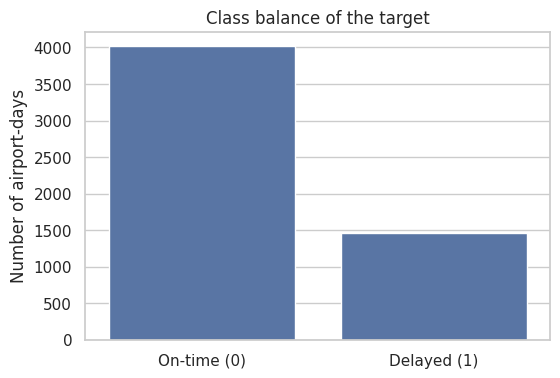

In [6]:
df["is_delayed"] = (df["delay_per_arr"] >= 1).astype(int)

counts = df["is_delayed"].value_counts().sort_index()
print(counts)
print("Positive (delayed) rate:", round(df["is_delayed"].mean(), 4))

plt.figure(figsize=(6, 4))
sns.countplot(x="is_delayed", data=df)
plt.xticks([0, 1], ["On-time (0)", "Delayed (1)"])
plt.title("Class balance of the target")
plt.xlabel("")
plt.ylabel("Number of airport-days")
plt.show()

**Interpretation:** about **27%** of airport-days are delayed and **73%** are on-time.
The classes are **imbalanced** but not extremely so. We keep this in mind, because the
course warns that *accuracy can be misleading on imbalanced data* — a model could look
good simply by predicting "on-time" most of the time. That is why we will also report
precision, recall and F1 for the delayed class, not just accuracy.

## 4. Select features and avoid data leakage

**Data leakage** (covered in the course) happens when a feature secretly contains the
answer. Our target is built from `delay_per_arr`, which itself comes from the delay
columns (`DLY_APT_ARR_1`, `FLT_ARR_1_DLY`, the weather-delay columns, `pct_arr_delayed`,
…). If we fed any of those to the model it would just be reading the answer off its own
input, and the evaluation would be meaningless. **So every delay-derived column is
excluded from the features.**

We also drop columns that carry no usable signal:

* `type`, `scheduled_service` — constant (every row is a large airport with scheduled service).
* `latitude_deg`, `longitude_deg`, `elevation_ft` — constant within each airport, so they
  are redundant with the airport's identity.
* `FLT_TOT_1` — it is exactly `FLT_DEP_1 + FLT_ARR_1`, so keeping all three would be
  perfect multicollinearity.
* `APT_ICAO`, `APT_NAME`, `iso_country`, `iso_region`, `municipality` — all one-to-one with
  the country, so we keep just **`STATE_NAME`** to represent the airport.

We keep only information that is genuinely **known before the day's delays happen**:

In [7]:
num_features = ["FLT_DEP_1", "FLT_ARR_1", "year"]
cat_features = ["STATE_NAME", "season", "day_of_week"]

X = df[num_features + cat_features].copy()
y = df["is_delayed"]

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (5477, 6)


,FLT_DEP_1,FLT_ARR_1,year,STATE_NAME,season,day_of_week
0,252,221,2023,Austria,Winter,Sunday
1,183,172,2023,Belgium,Winter,Sunday
2,246,238,2023,Denmark,Winter,Sunday
3,292,283,2023,Ireland,Winter,Sunday
4,299,290,2023,Portugal,Winter,Sunday


**Why `season` (a category) instead of the numeric month?** Logistic Regression is a
**linear** model. A numeric month would force the effect to change in a straight line
from January (1) to December (12), which makes no sense for weather/seasonal patterns
(December and January are both winter but are numerically far apart). Encoding the
**season** as a category lets the model learn a separate effect for each season, which
matches the seasonal pattern we saw in the Phase 3 EDA (a summer peak).

## 5. Train / test split

We split the data so the model is trained on one part and honestly tested on data it has
never seen.  we use an **80% / 20%**
split and set `random_state` to a **student ID (1222212)** so the split is reproducible.
We also `stratify` on the target so the 27% delayed rate is preserved in both sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1222212, stratify=y)

print("Train rows:", X_train.shape[0])
print("Test rows: ", X_test.shape[0])
print("Train delayed rate:", round(y_train.mean(), 3))
print("Test delayed rate: ", round(y_test.mean(), 3))

Train rows: 4381
Test rows:  1096
Train delayed rate: 0.267
Test delayed rate:  0.267


## 6. Preprocessing pipeline

We build the same kind of preprocessing pipeline shown in the course's end-to-end example:

* **Numeric features** → fill any missing value with the median, then **StandardScaler**
  (mean 0, standard deviation 1) so all features are on a comparable scale.
* **Categorical features** → fill any missing value with the most frequent value, then
  **OneHotEncoder** (`handle_unknown='ignore'` so an unseen category does not crash the model).

The two pipelines are combined in a single **ColumnTransformer**. Fitting it only on the
training data (inside the model pipeline below) is what keeps the test set unseen and
prevents leakage.

In [9]:
num_pipe = make_pipeline(SimpleImputer(strategy="median"),
                         StandardScaler())
cat_pipe = make_pipeline(SimpleImputer(strategy="most_frequent"),
                         OneHotEncoder(handle_unknown="ignore", sparse_output=False))

preprocessor = ColumnTransformer(
    [("numeric", num_pipe, num_features),
     ("categorical", cat_pipe, cat_features)],
    verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['FLT_DEP_1', 'FLT_ARR_1', 'year']),
                                ('categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['STATE_NAME', 'season', 'day_of_week'])],
                  verbose_feature_names_out=False)

### 7. Fit the Logistic Regression model

**Logistic Regression** is the binary classifier taught in the course. Instead of fitting a
straight line like Linear Regression, it passes a linear combination of the features through
the **sigmoid function**, which squeezes the output into the range 0–1 and is read as the
**probability that the day is delayed**. If that probability is above 0.5 the model predicts
*delayed (1)*, otherwise *on-time (0)*.

We combine the preprocessor and the classifier into one `Pipeline` so that preprocessing and
prediction always happen together.

In [10]:
model = make_pipeline(preprocessor,
                     LogisticRegression(max_iter=1000, random_state=1222212))
model.fit(X_train, y_train)
model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['FLT_DEP_1', 'FLT_ARR_1',
                                                   'year']),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['STATE_NAME', 'season',
                                                   'day_of_week'])],
                                   verbose_feature_names_out=False)),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, random_state=1222212))])

## 8. Interpret the model coefficients

Like Linear Regression, Logistic Regression gives a **weight (coefficient)** to each feature.
A **positive** weight pushes the predicted probability of *delay* **up**; a **negative**
weight pushes it **down**. Because the numeric features were standardised, the weights are
roughly comparable in size.

In [11]:
feat_names = model.named_steps["columntransformer"].get_feature_names_out()
coefs      = model.named_steps["logisticregression"].coef_[0]
intercept  = model.named_steps["logisticregression"].intercept_[0]

coef_table = (pd.DataFrame({"feature": feat_names, "coefficient": coefs})
                .sort_values("coefficient", ascending=False)
                .reset_index(drop=True))
print("Intercept:", round(intercept, 3))
coef_table

Intercept: -0.854


,feature,coefficient
0,STATE_NAME_Portugal,2.467489
1,FLT_ARR_1,0.278343
2,FLT_DEP_1,0.210237
3,day_of_week_Monday,0.179168
4,day_of_week_Saturday,0.066990
5,season_Summer,-0.003341
6,season_Spring,-0.073453
7,day_of_week_Friday,-0.075525
8,day_of_week_Sunday,-0.099996
9,day_of_week_Thursday,-0.113246


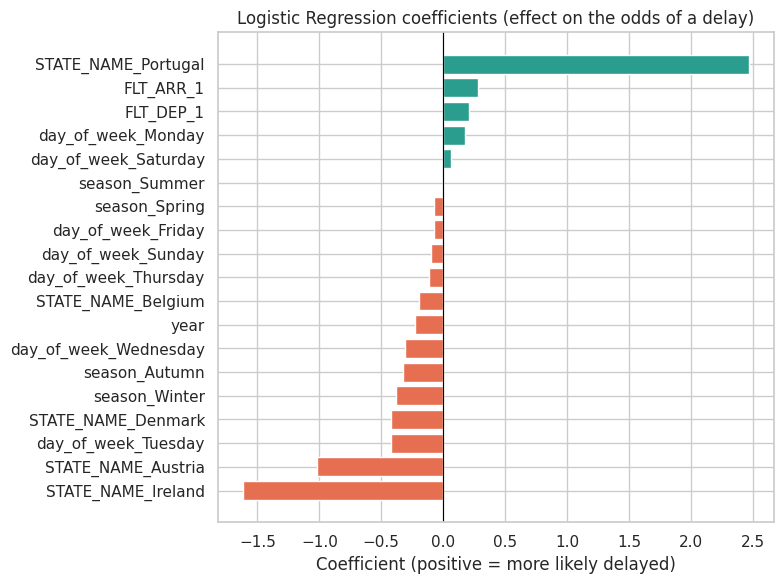

In [12]:
plt.figure(figsize=(8, 6))
colors = ["#2a9d8f" if c >= 0 else "#e76f51" for c in coef_table["coefficient"]]
plt.barh(coef_table["feature"], coef_table["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression coefficients (effect on the odds of a delay)")
plt.xlabel("Coefficient (positive = more likely delayed)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretation:** the model's weights agree with the Phase 3 EDA.

* **`STATE_NAME_Portugal`** has by far the strongest positive weight — Lisbon is delayed on
  most days, so being in Portugal sharply raises the predicted delay probability.
* **`STATE_NAME_Ireland`** and **`STATE_NAME_Austria`** have the strongest negative weights —
  Dublin and Vienna are usually on-time.
* **`FLT_ARR_1`** and **`FLT_DEP_1`** are positive: **busier days are more likely to be delayed**,
  which matches the intuition that congestion causes delay.
* Among seasons, **Summer** sits highest and **Winter** lowest, reproducing the summer peak we
  observed earlier.

So the model is not a black box — its reasoning is interpretable and consistent with the data.

## 9. Evaluate the model

We evaluate on both the training and the test set, using the classification metrics taught in
the course: **accuracy, precision, recall and F1**. We define a small helper (mirroring the
course's `regression_metrics` helper) to print them cleanly.

In [13]:
def classification_metrics(y_true, y_pred, label=""):
    header = "-" * 55
    print(header, f"Classification Metrics: {label}", header, sep="\n")
    print(f"- Accuracy  = {accuracy_score(y_true, y_pred):.3f}")
    print(f"- Precision = {precision_score(y_true, y_pred):.3f}")
    print(f"- Recall    = {recall_score(y_true, y_pred):.3f}")
    print(f"- F1-score  = {f1_score(y_true, y_pred):.3f}")

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

classification_metrics(y_train, y_train_pred, "Training Data")
print()
classification_metrics(y_test,  y_test_pred,  "Test Data")

-------------------------------------------------------
Classification Metrics: Training Data
-------------------------------------------------------
- Accuracy  = 0.842
- Precision = 0.774
- Recall    = 0.574
- F1-score  = 0.659

-------------------------------------------------------
Classification Metrics: Test Data
-------------------------------------------------------
- Accuracy  = 0.851
- Precision = 0.795
- Recall    = 0.597
- F1-score  = 0.682


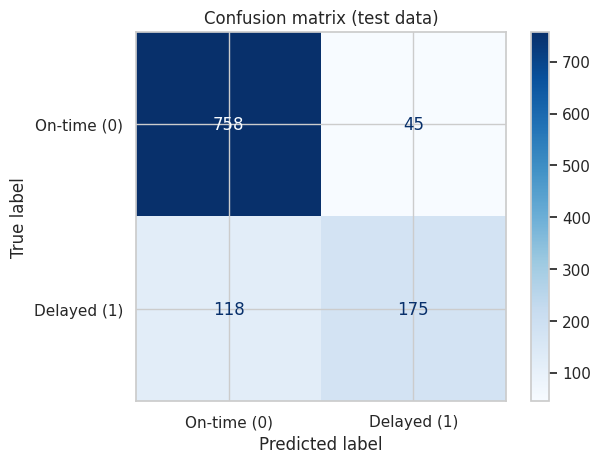

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=["On-time (0)", "Delayed (1)"], cmap="Blues")
plt.title("Confusion matrix (test data)")
plt.show()

In [15]:
print(classification_report(
    y_test, y_test_pred, target_names=["On-time (0)", "Delayed (1)"]))

              precision    recall  f1-score   support

 On-time (0)       0.87      0.94      0.90       803
 Delayed (1)       0.80      0.60      0.68       293

    accuracy                           0.85      1096
   macro avg       0.83      0.77      0.79      1096
weighted avg       0.85      0.85      0.84      1096



**Interpretation.** On the test set the model reaches about **85% accuracy**. But, exactly as
the course warns, accuracy alone hides the imbalance, so we read the per-class numbers:

* **On-time days** are predicted very well — recall ≈ 0.94 (the model correctly flags almost
  all calm days).
* **Delayed days** are harder — precision ≈ 0.80 but recall ≈ 0.60, meaning that when the model
  says "delayed" it is usually right, but it still **misses about 40% of the delayed days**.

In the confusion matrix this shows up as a larger number of **false negatives** (delayed days
predicted as on-time). This is the expected behaviour of a simple linear model on imbalanced
data, and it is the model's main weakness.

## 10. Under-fitting / over-fitting check

The course's rule: compare train and test quality. A large gap means **over-fitting**; poor
quality on both means **under-fitting**.

In [16]:
summary = pd.DataFrame({
    "Train": [accuracy_score(y_train, y_train_pred), f1_score(y_train, y_train_pred)],
    "Test":  [accuracy_score(y_test,  y_test_pred),  f1_score(y_test,  y_test_pred)]},
    index=["Accuracy", "F1-score"]).round(3)
print(summary)

          Train   Test
Accuracy  0.842  0.851
F1-score  0.659  0.682


**Interpretation.** Training and test scores are almost identical (accuracy ≈ 0.84 vs 0.85,
F1 ≈ 0.66 vs 0.68). There is **no gap**, so the model is **not over-fitting**. It is also not
badly under-fitting — accuracy and the on-time scores are high. The one soft spot is the
moderate **recall on delayed days**, which points less to over/under-fitting and more to the
class imbalance and the limits of a simple linear model. The course's suggested fixes (more
informative features, or more data) are discussed in the conclusion.

## 11. Predict new airport-days

Finally we use the trained model on two brand-new, hand-written examples to see it in action.
We also print `predict_proba`, the probability the model assigns to each class.

In [17]:
def describe(row):
    X_one = pd.DataFrame([row], columns=num_features + cat_features)
    proba = model.predict_proba(X_one)[0]
    pred  = model.predict(X_one)[0]
    print(row)
    print(f"  P(on-time) = {proba[0]:.2f}   P(delayed) = {proba[1]:.2f}   ->  "
          f"{'DELAYED' if pred == 1 else 'ON-TIME'}\n")

# Busy summer Monday in Lisbon (Portugal)
describe([360, 360, 2025, "Portugal", "Summer", "Monday"])

# Quiet winter Tuesday in Dublin (Ireland)
describe([250, 250, 2025, "Ireland", "Winter", "Tuesday"])

[360, 360, 2025, 'Portugal', 'Summer', 'Monday']
  P(on-time) = 0.13   P(delayed) = 0.87   ->  DELAYED

[250, 250, 2025, 'Ireland', 'Winter', 'Tuesday']
  P(on-time) = 0.98   P(delayed) = 0.02   ->  ON-TIME



**Interpretation.** The model behaves sensibly: a busy summer day in Lisbon is predicted as
**delayed** with high probability, while a quiet winter day in Dublin is predicted as
**on-time**. This matches everything we learned about these airports in the earlier phases.

## 12. Conclusion and discussion

**What we built.**  we trained a **Logistic Regression**
classifier that predicts whether a European airport will have a **delayed** or **on-time** day,
from information known in advance: how busy the airport is, which airport/country it is, the
season, the weekday and the year.

**What the results mean.** The model reaches **~85% test accuracy with no over-fitting** (train
and test scores match). It is excellent at recognising on-time days and reasonably precise about
delayed days (~80% precision), but it **misses about 40% of delayed days** (recall ≈ 0.60). The
coefficients are interpretable and confirm the story from our exploratory analysis: **Lisbon and
busy days drive delays, while Dublin and Vienna are usually punctual, with a mild summer peak.**

**Why it matters.** Even a simple model is useful: it tells an airport which combinations of
location, traffic load and time of year are most likely to produce delays, which could support
staffing and scheduling decisions.

**Limitations.**
* The dataset is only **five major airports**, so the model learns strong airport-specific effects
  and may not generalise to other airports.
* The target comes from **ATFM arrival delay only** — other delay causes are not captured.
* We could not use weather as an input: this dataset's weather columns are *weather-attributed
  delay minutes*, which are derived from the delay itself and would cause **leakage**. Real weather
  measurements (temperature, wind, visibility) are the most promising missing feature.

